In [1]:
from src.configmanager.experimentconfigmanager import *
global_hparams = {
    "lr"                : 0.00005,
    "n_epochs"          : 250,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.75, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'outbreakweighted',
    'patience'          : 20,
    }


train_hparams = {'verbose':2 , 
                 'dataloader_snapshot': False, 
                 'show_loss' : False}

config = ExperimentConfig(
    name='measles_gatv2',
    data=DataConfig(
        disease_name    = 'measles',
        nuts_level      = 'nuts3',
        min_date        = '2006-05-15',
        max_date        = '2020-06-01',
        split_berlin    = False,
        include_population= False

    ),
    timeseries=TimeSeriesConfig(
        horizon_size    = 1,
        horizon_leadtime= 1,
        sequence_length = 1,
        lags            = 1
    ),
    preprocessing=PreprocessingConfig(
        log_transform_target= False,
        add_time_features   = True,
        normalization_method='zscore'
    ),
    splits=SplitConfig(
        split_trainval  = '2017-06-01',
        split_valtest   = '2018-06-01',
    ),
    model= ['GATv2Model'],
    global_hparams = global_hparams,
    train_hparams  = train_hparams,
    graphs         = ['gravity1'],
    baseline = True
)
runner = ExperimentRunner()
evaluator = runner.define(config).execute('measles_gatv2')

interesting_nodes = [26,391, 69, 30]

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-05-01 (+2 weeks)
berlin districts removed

==    Training GATv2Model_gravity1    ==
Epoch 1 train loss: 2.6956, val loss: 0.5198 ✓ (new best)
Epoch 2 train loss: 2.5957, val loss: 0.5135 ✓ (new best)
Epoch 3 train loss: 2.4897, val loss: 0.5147 (patience: 1/20)
Epoch 4 train loss: 2.4302, val loss: 0.5198 (patience: 2/20)
Epoch 5 train loss: 2.3842, val loss: 0.5256 (patience: 3/20)
Epoch 6 train loss: 2.3670, val loss: 0.5252 (patience: 4/20)
Epoch 7 train loss: 2.2899, val loss: 0.5228 (patience: 5/20)
Epoch 8 train loss: 2.2621, val loss: 0.5175 (patience: 6/20)
Epoch 9 train loss: 2.2016, val loss: 0.5205 (patience: 7/20)
lr has been updated from 5.00e-05 to 3.75e-05
Epoch 10 train loss: 2.1967, val loss: 0.5169 (patience: 8/20)
Epoch 11 train loss: 2.1572, val loss: 0.5141 (patience: 9/20)
Epoch 12 train loss: 2.2331, val loss: 0.5167 (patience: 10/20)
Epoch 13 train loss: 2.1189, val loss: 0.5147 (pa

Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 503.20it/s]

Test loss: 0.7231


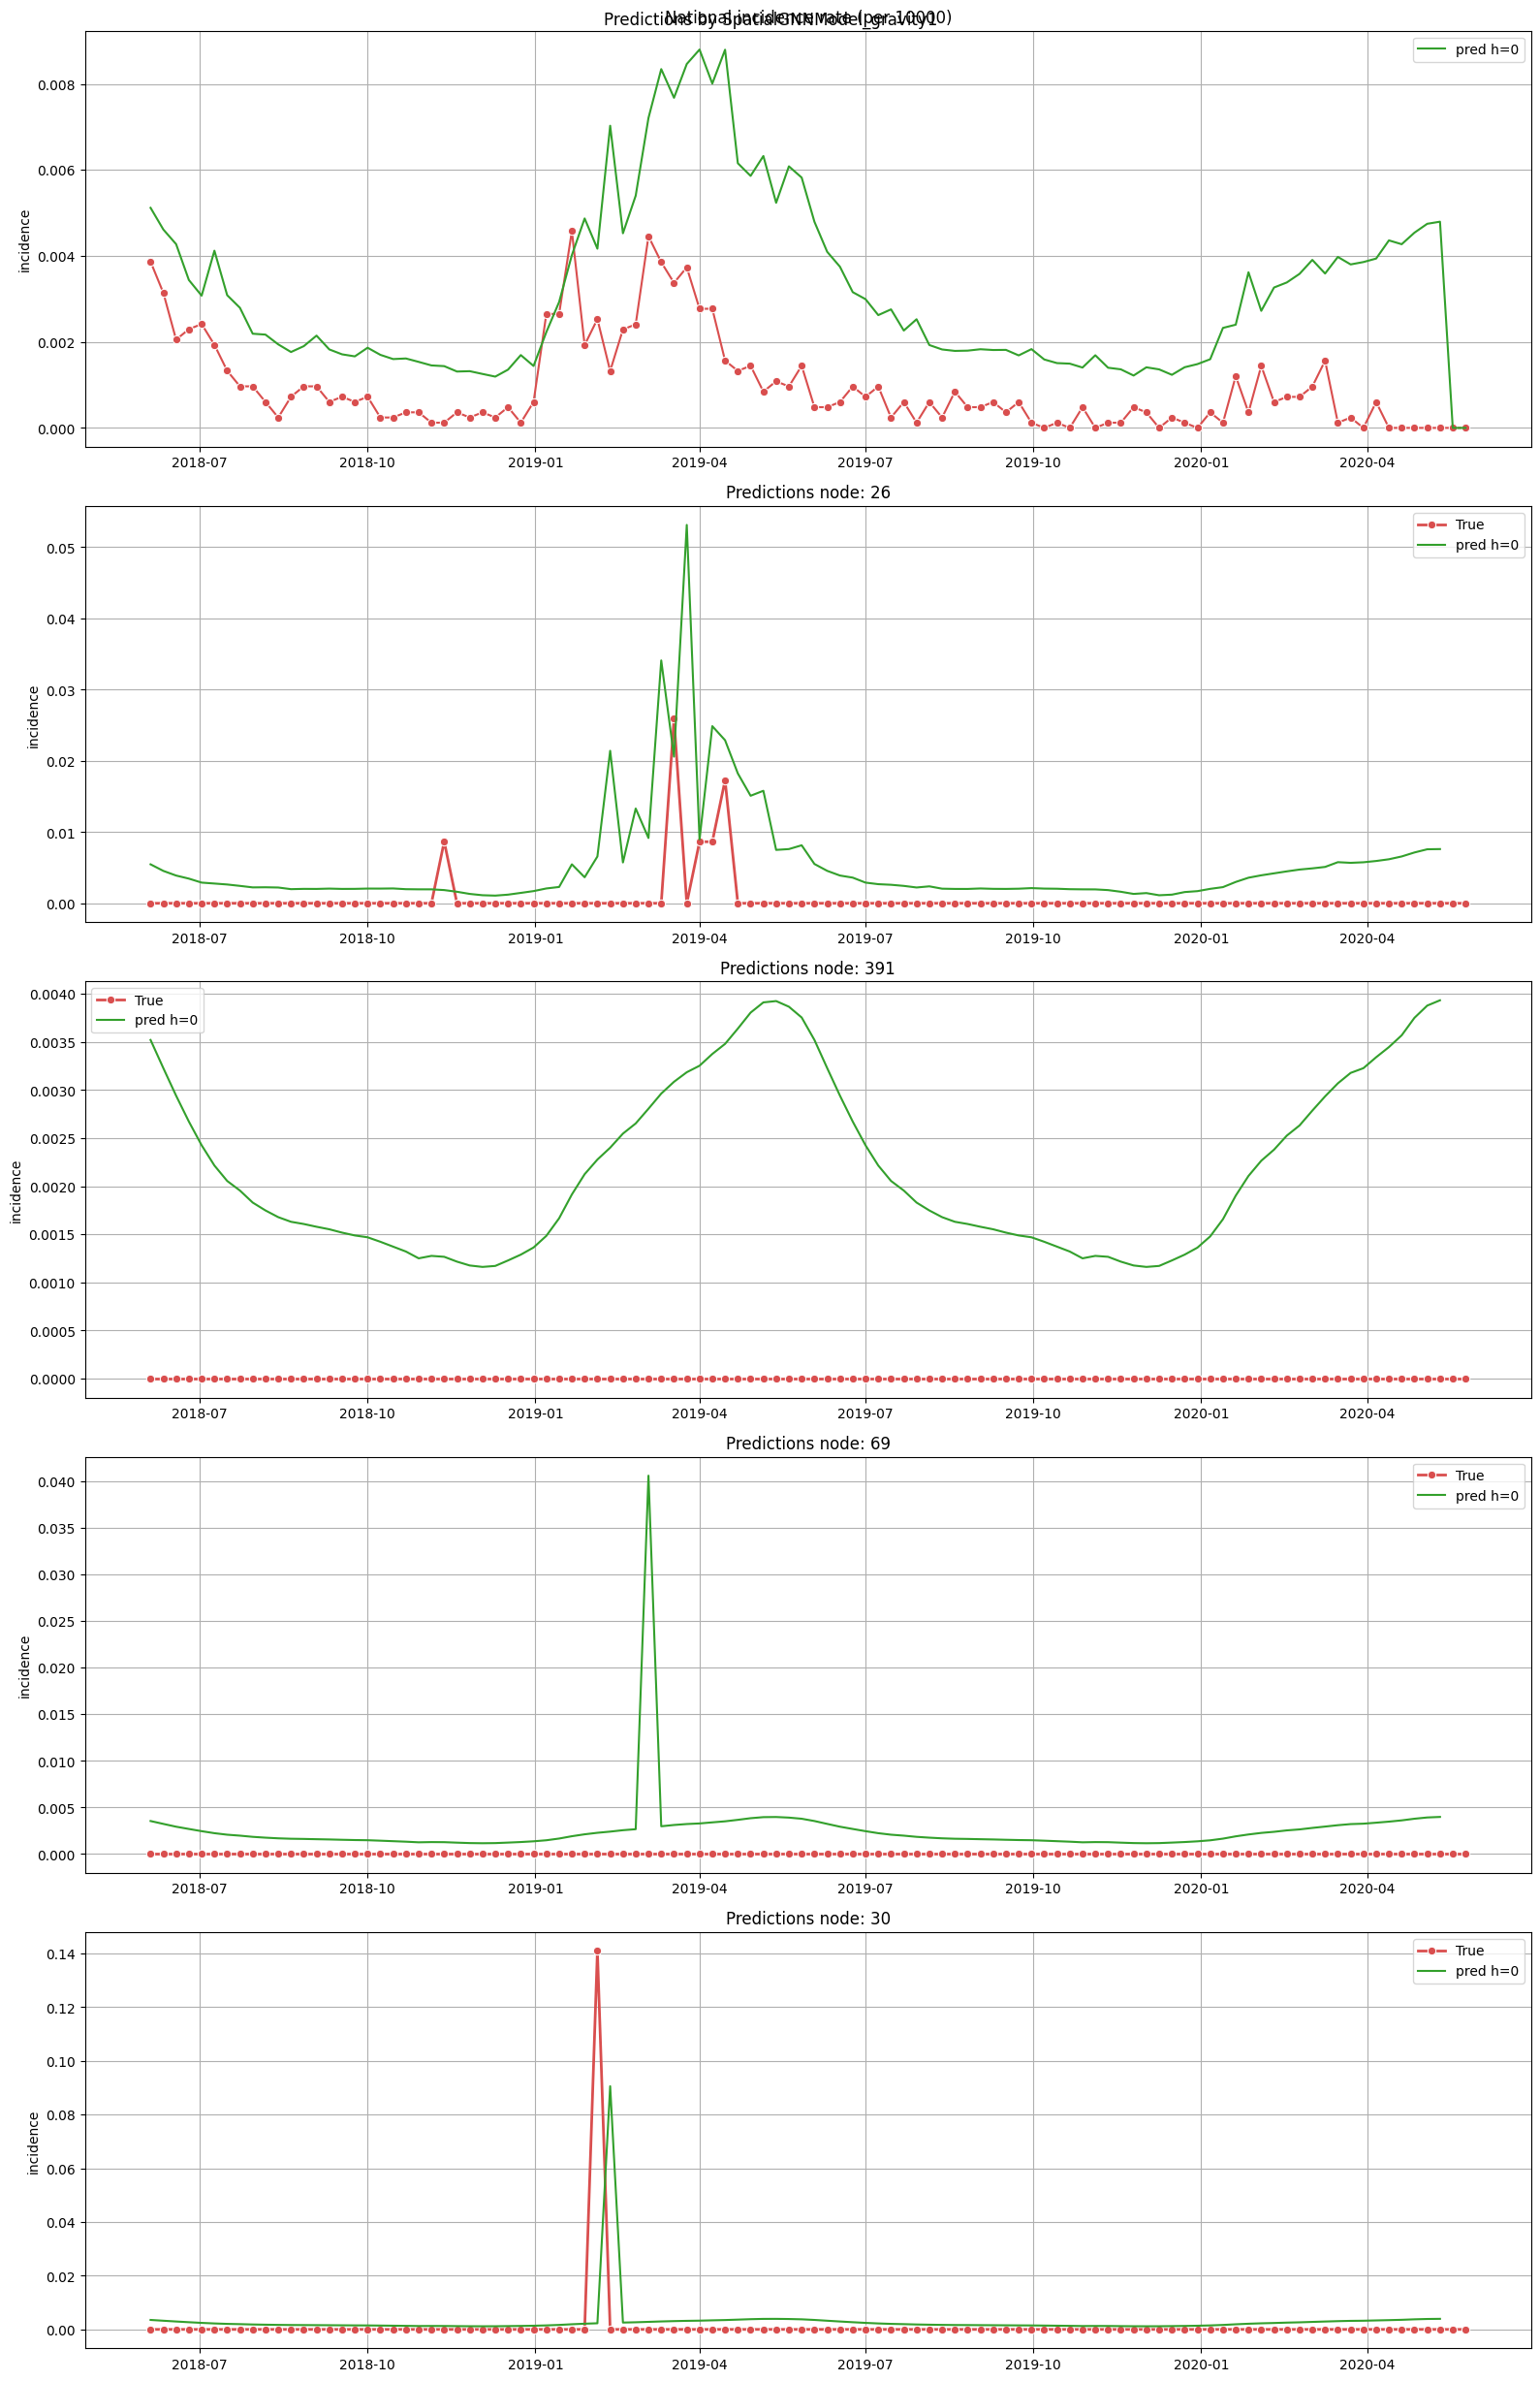

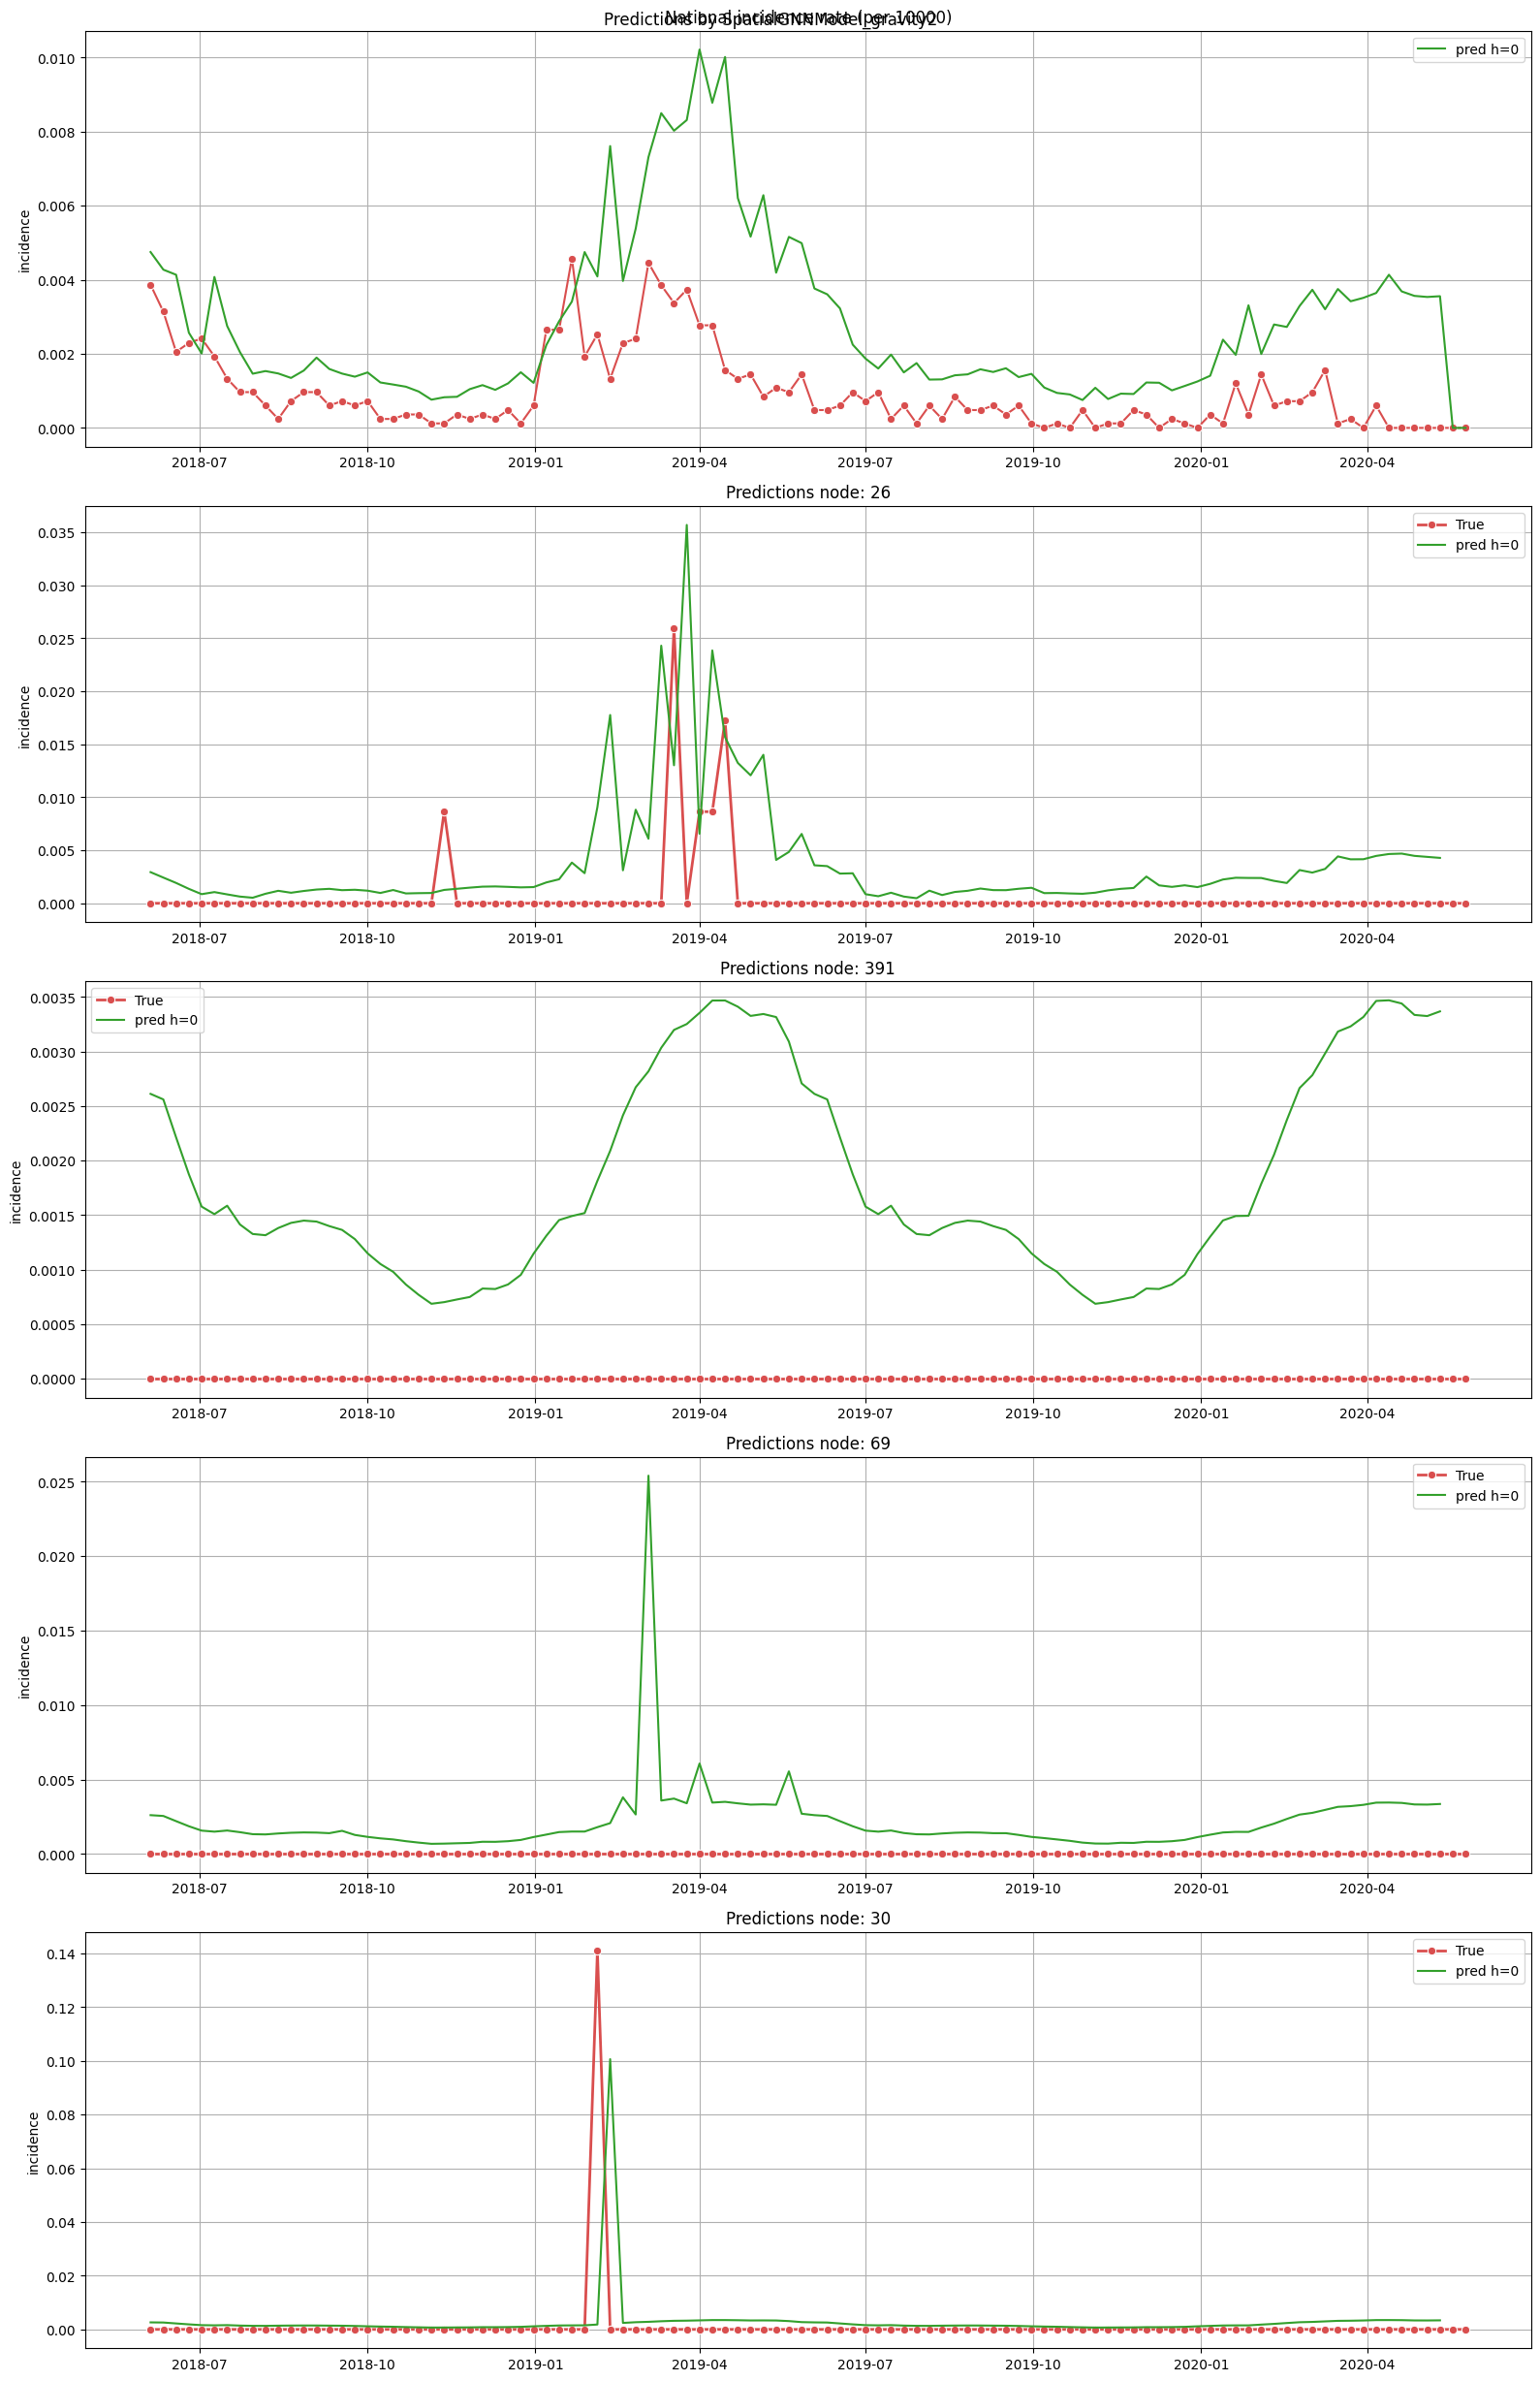

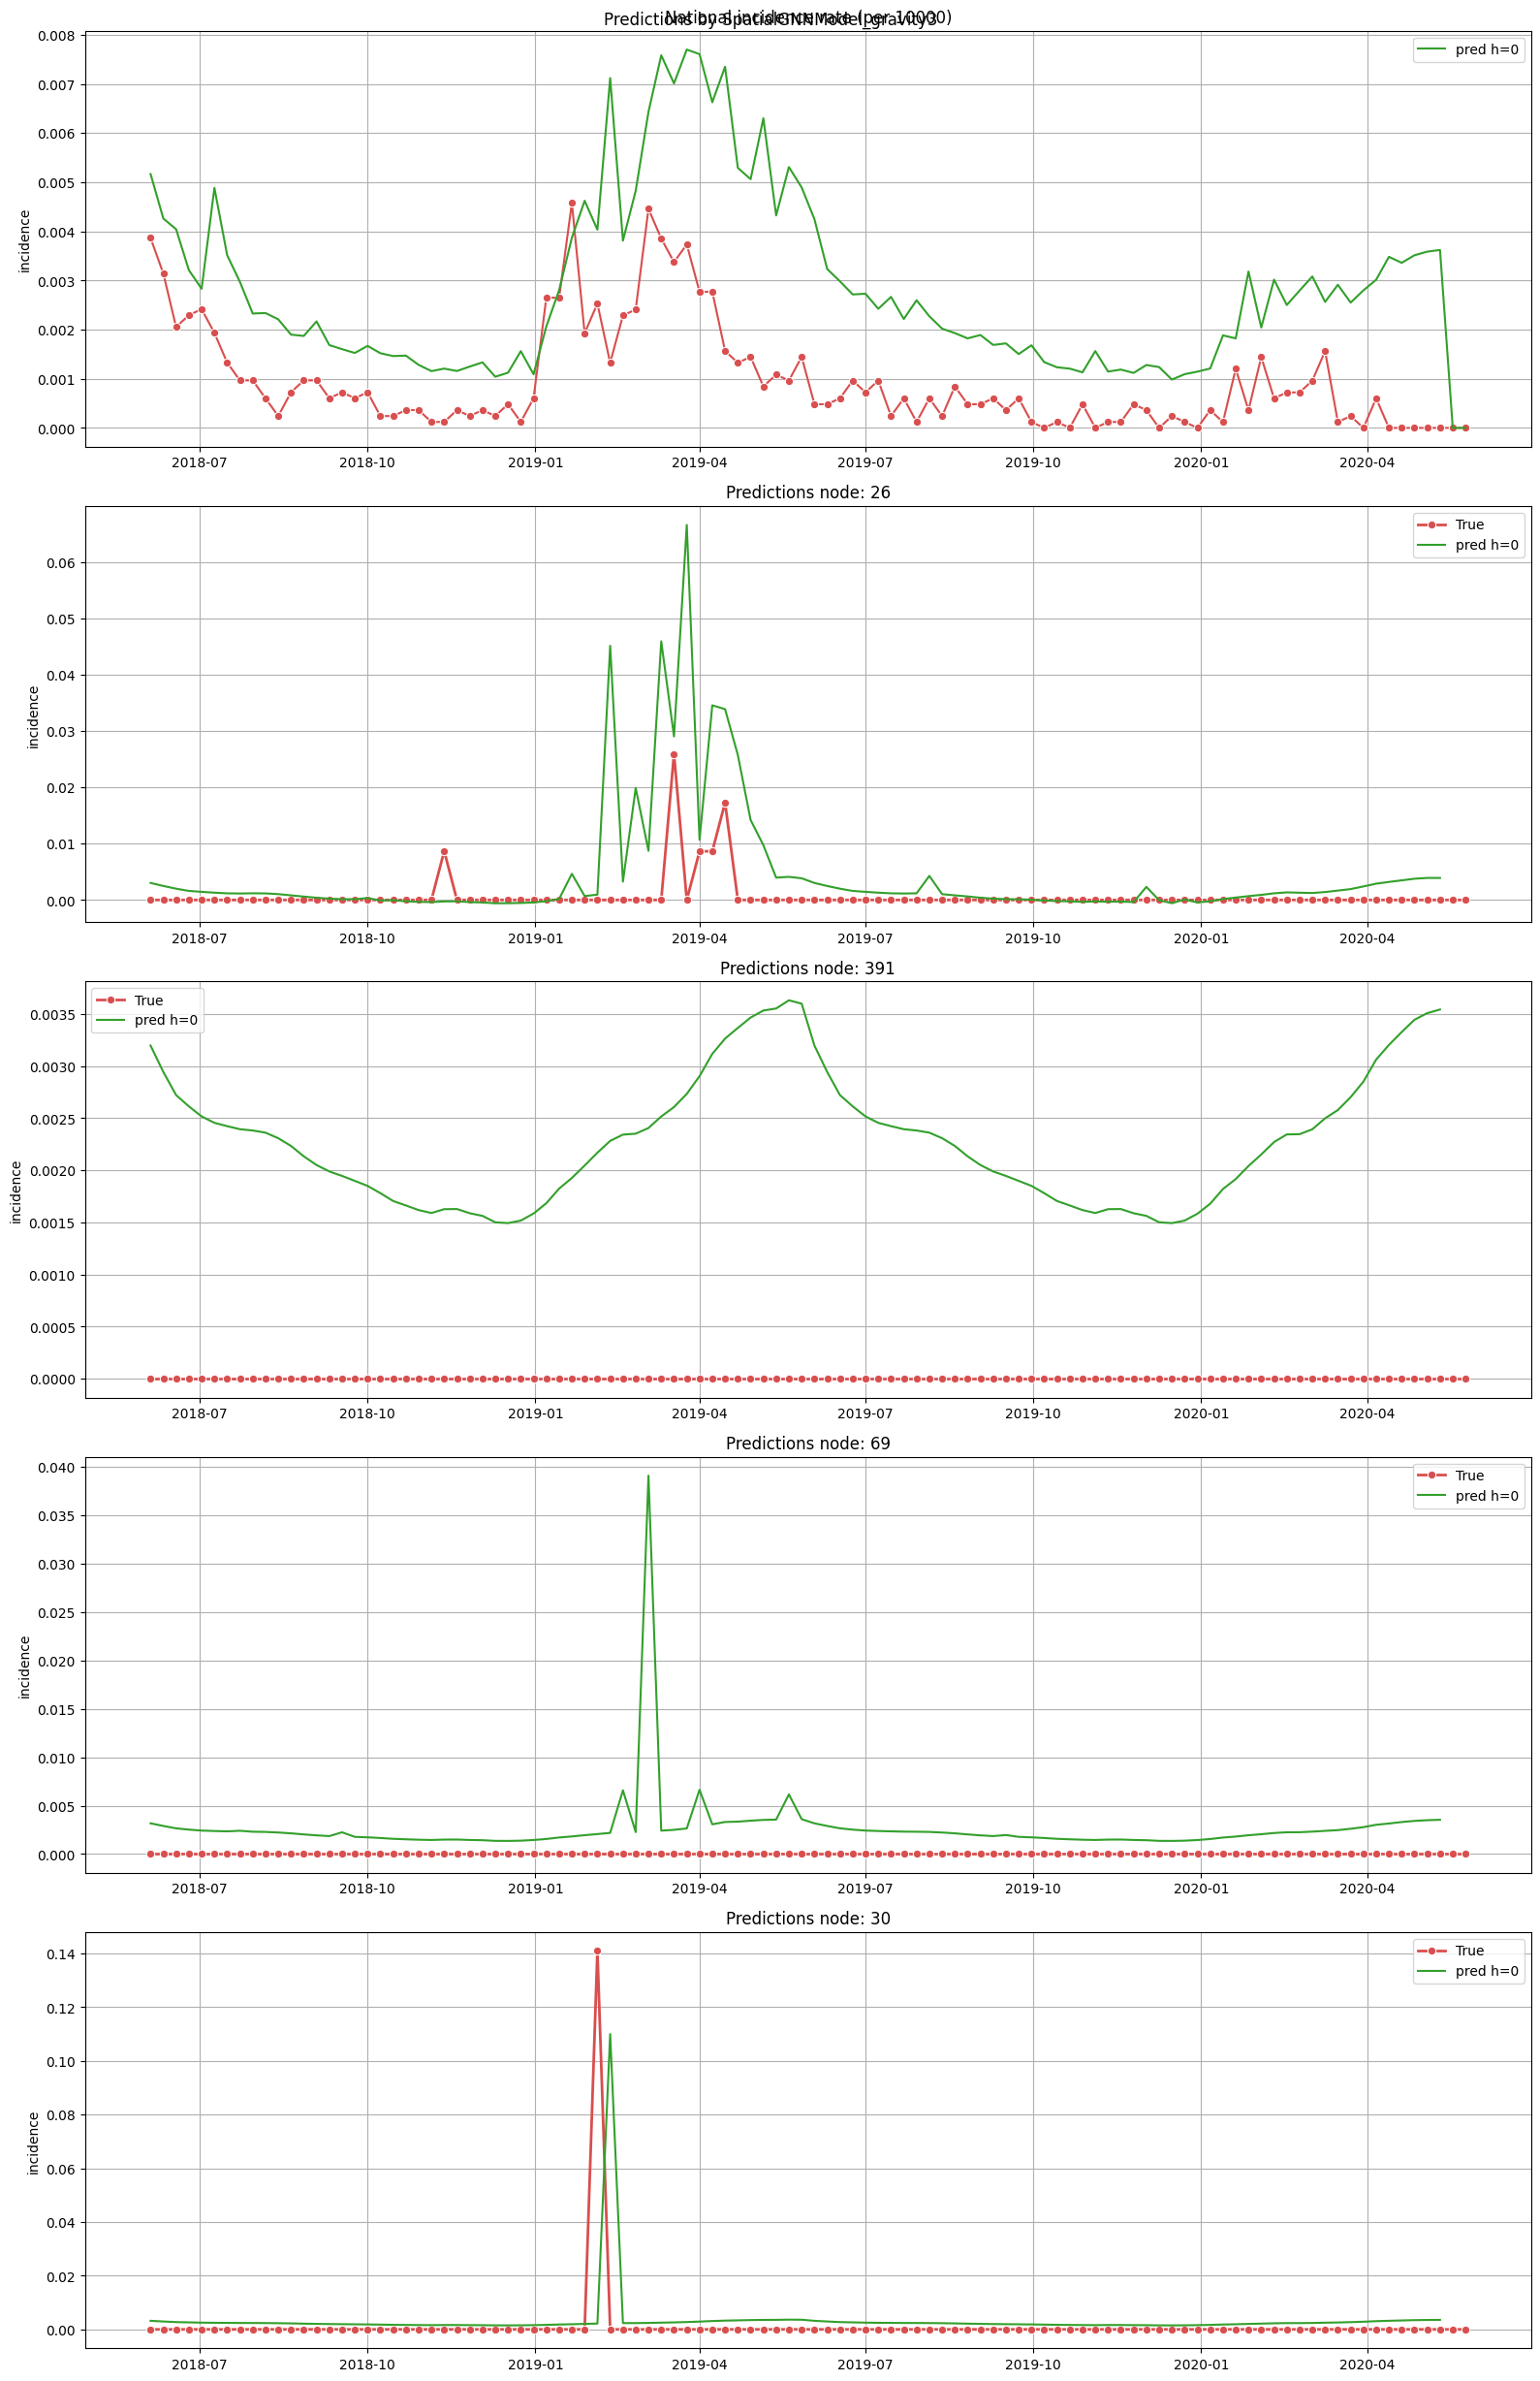

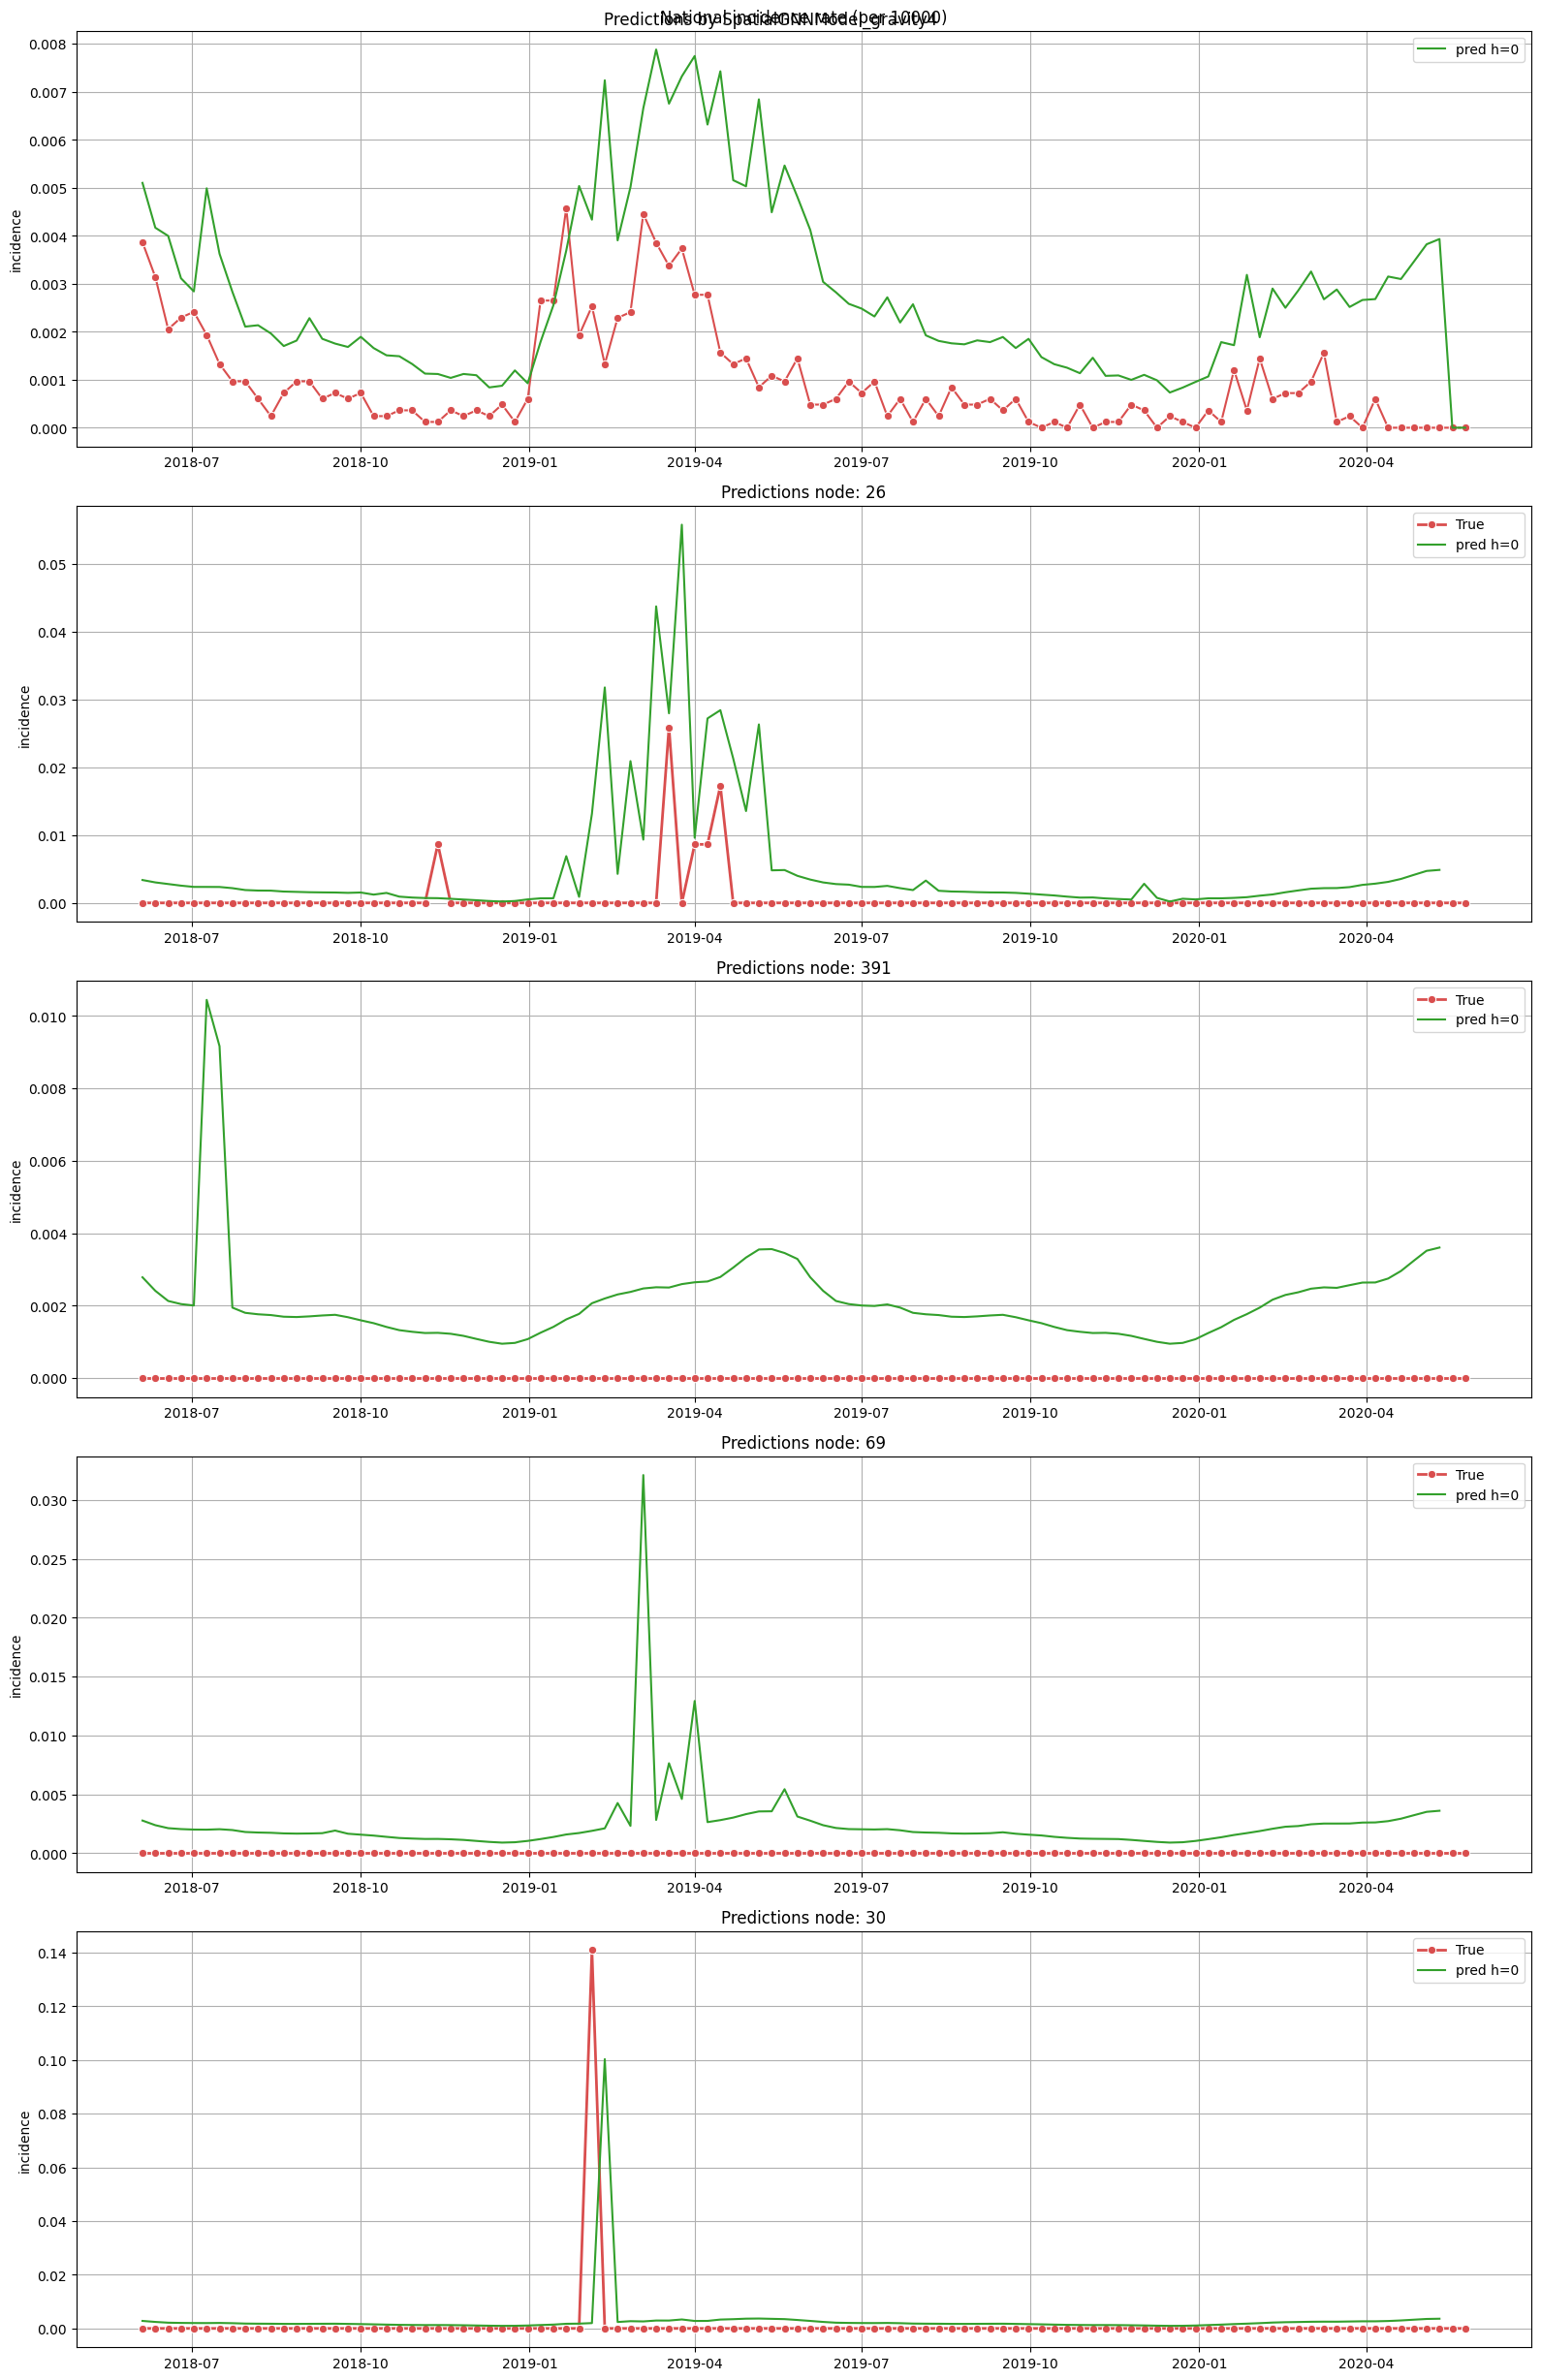

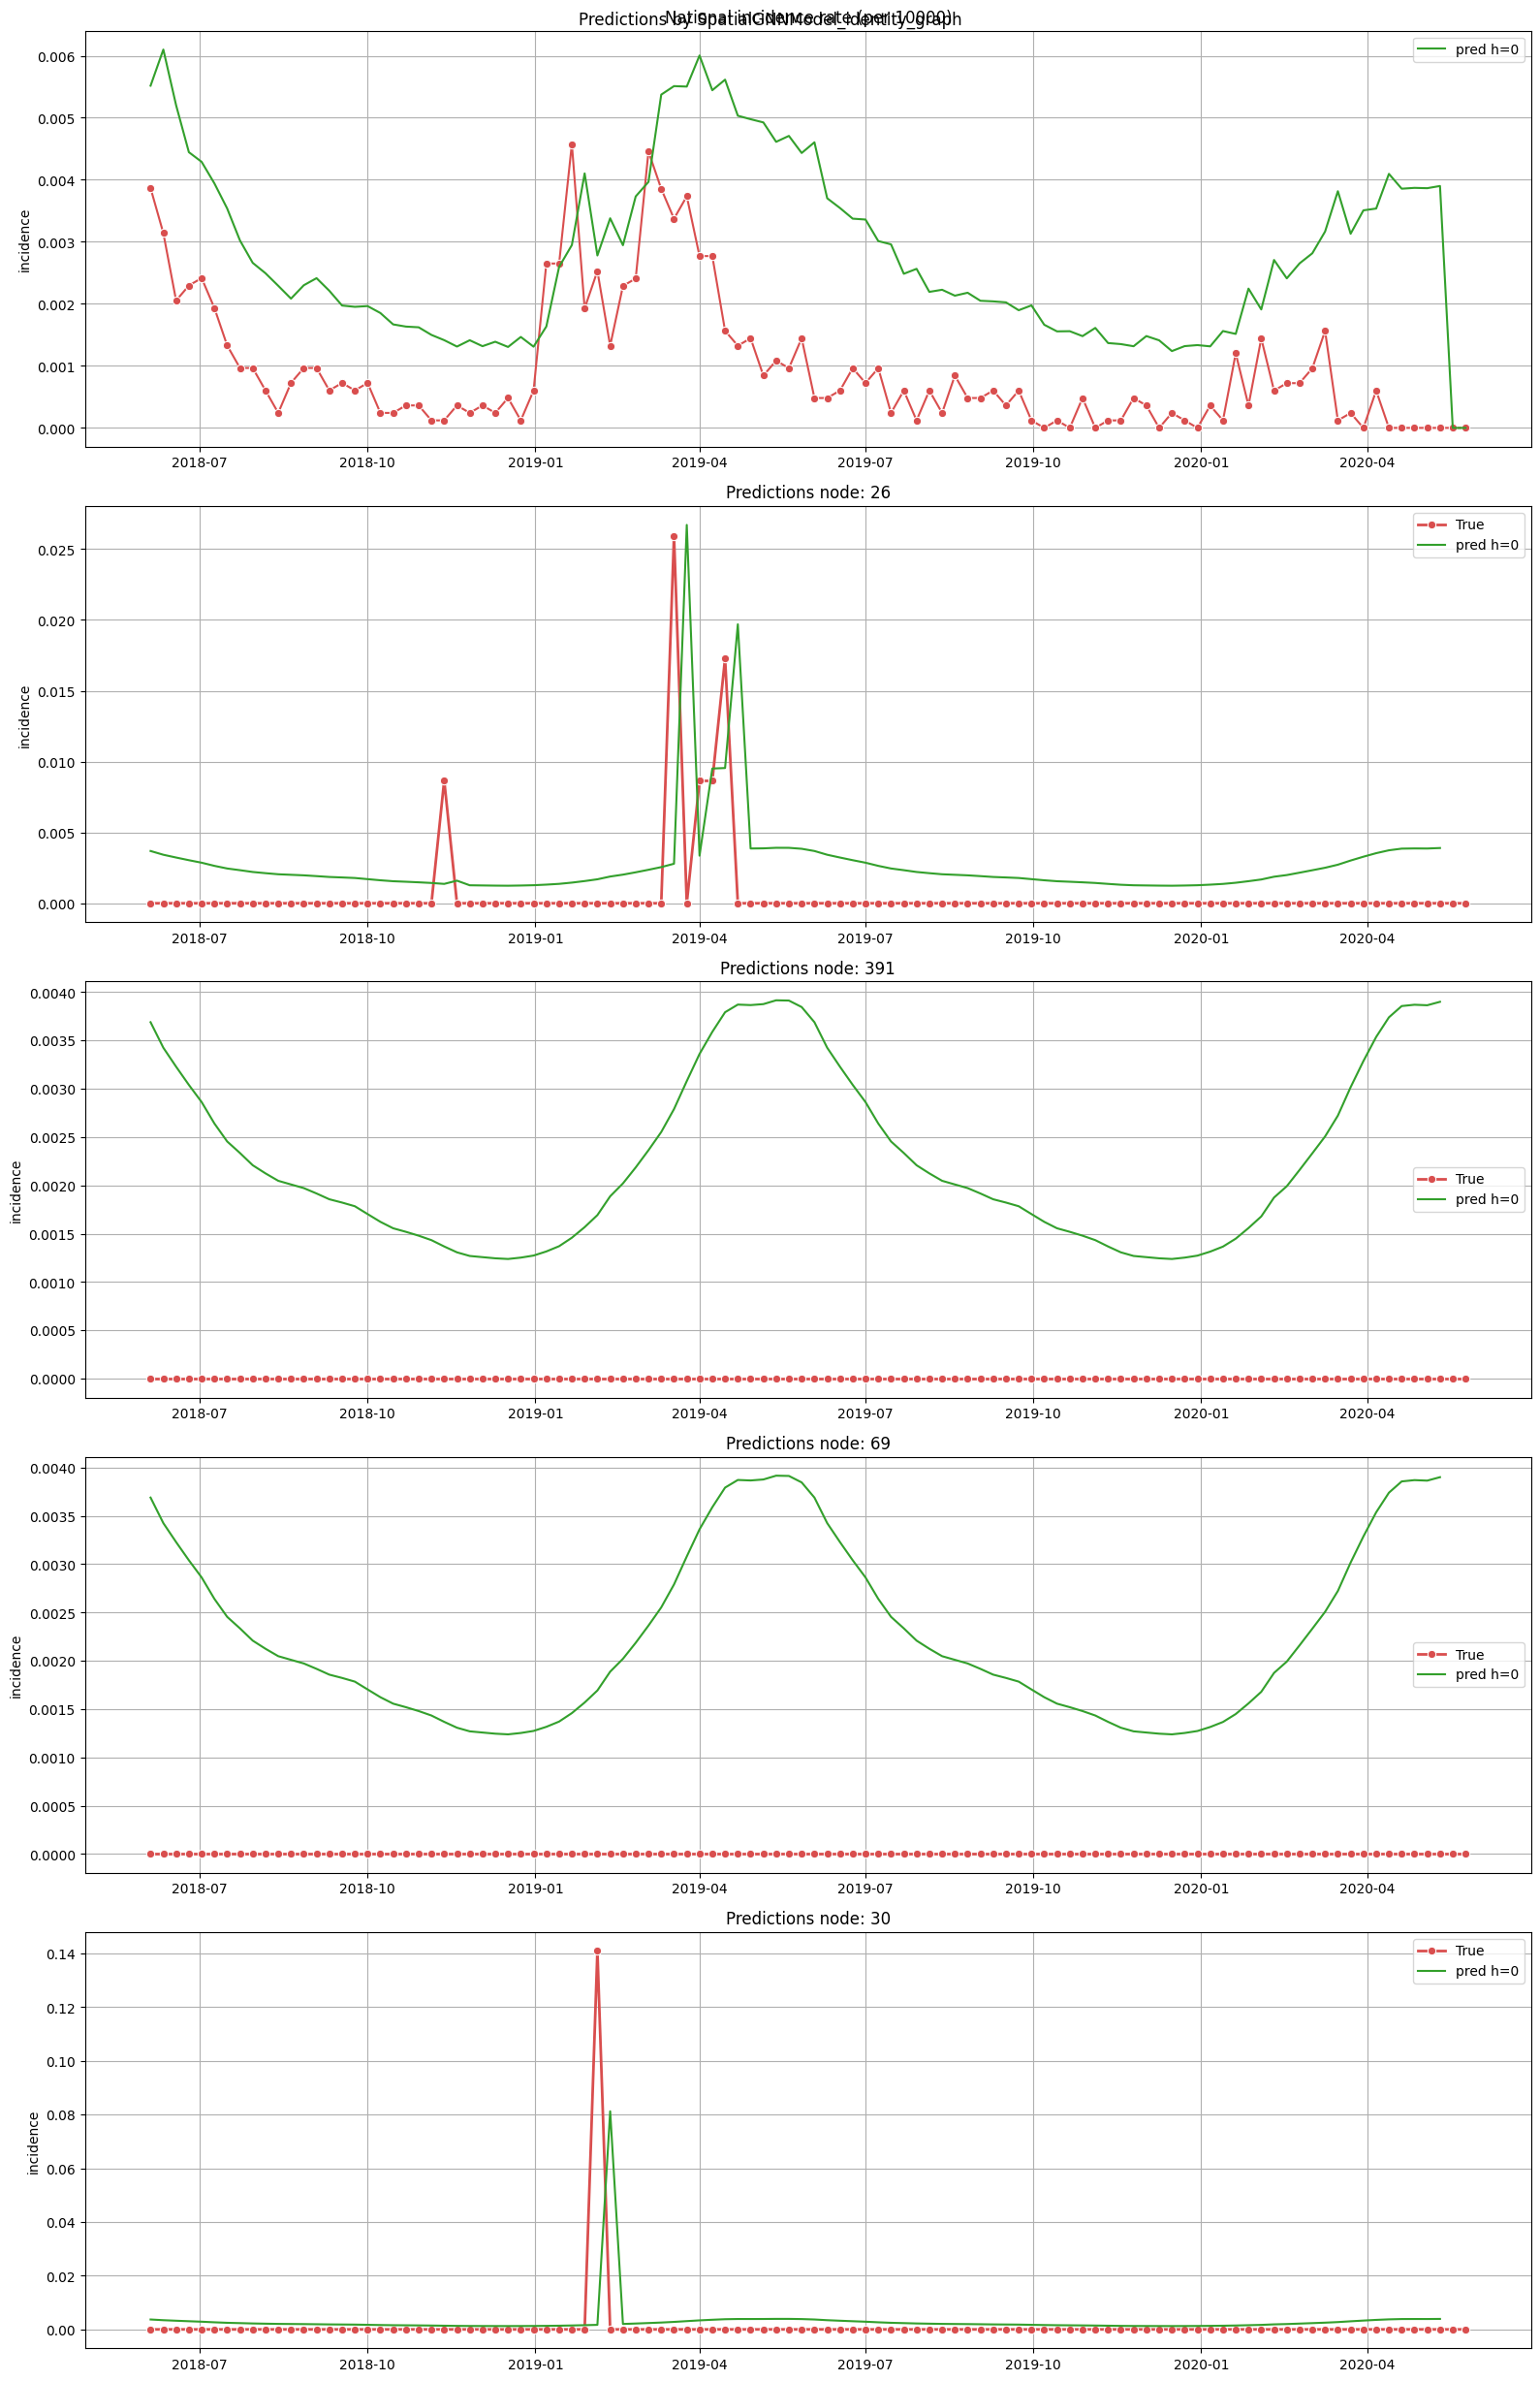

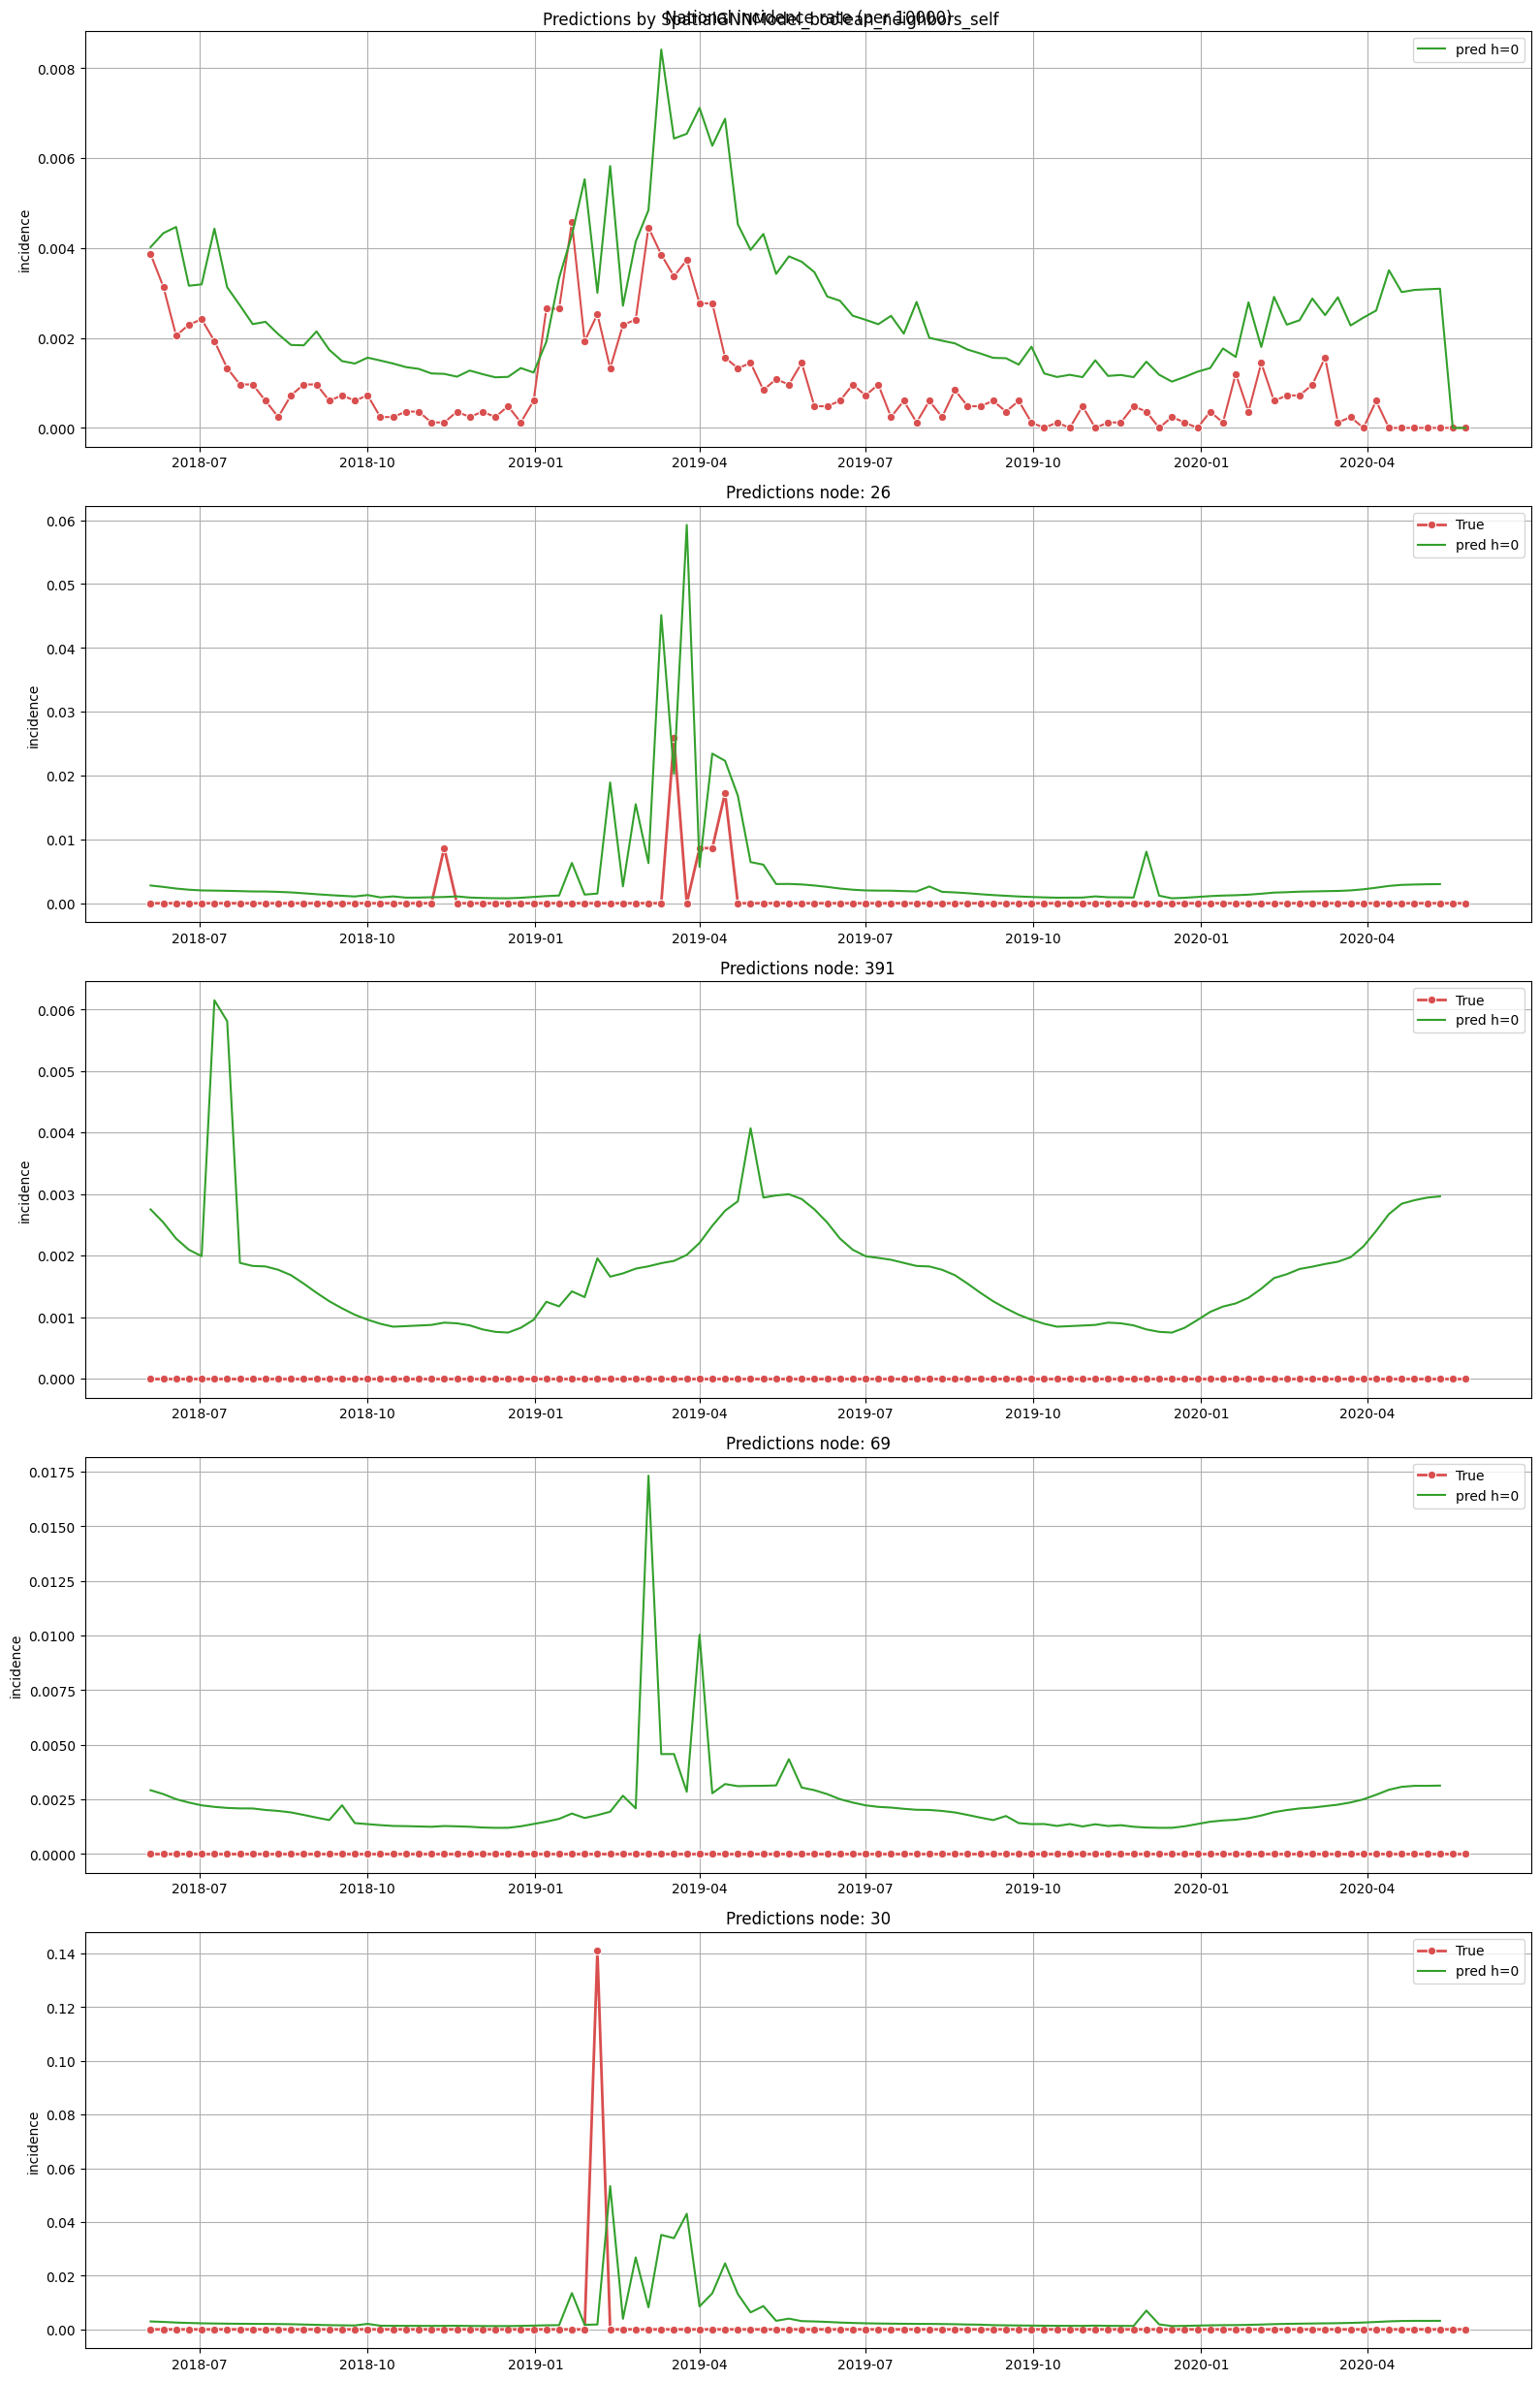

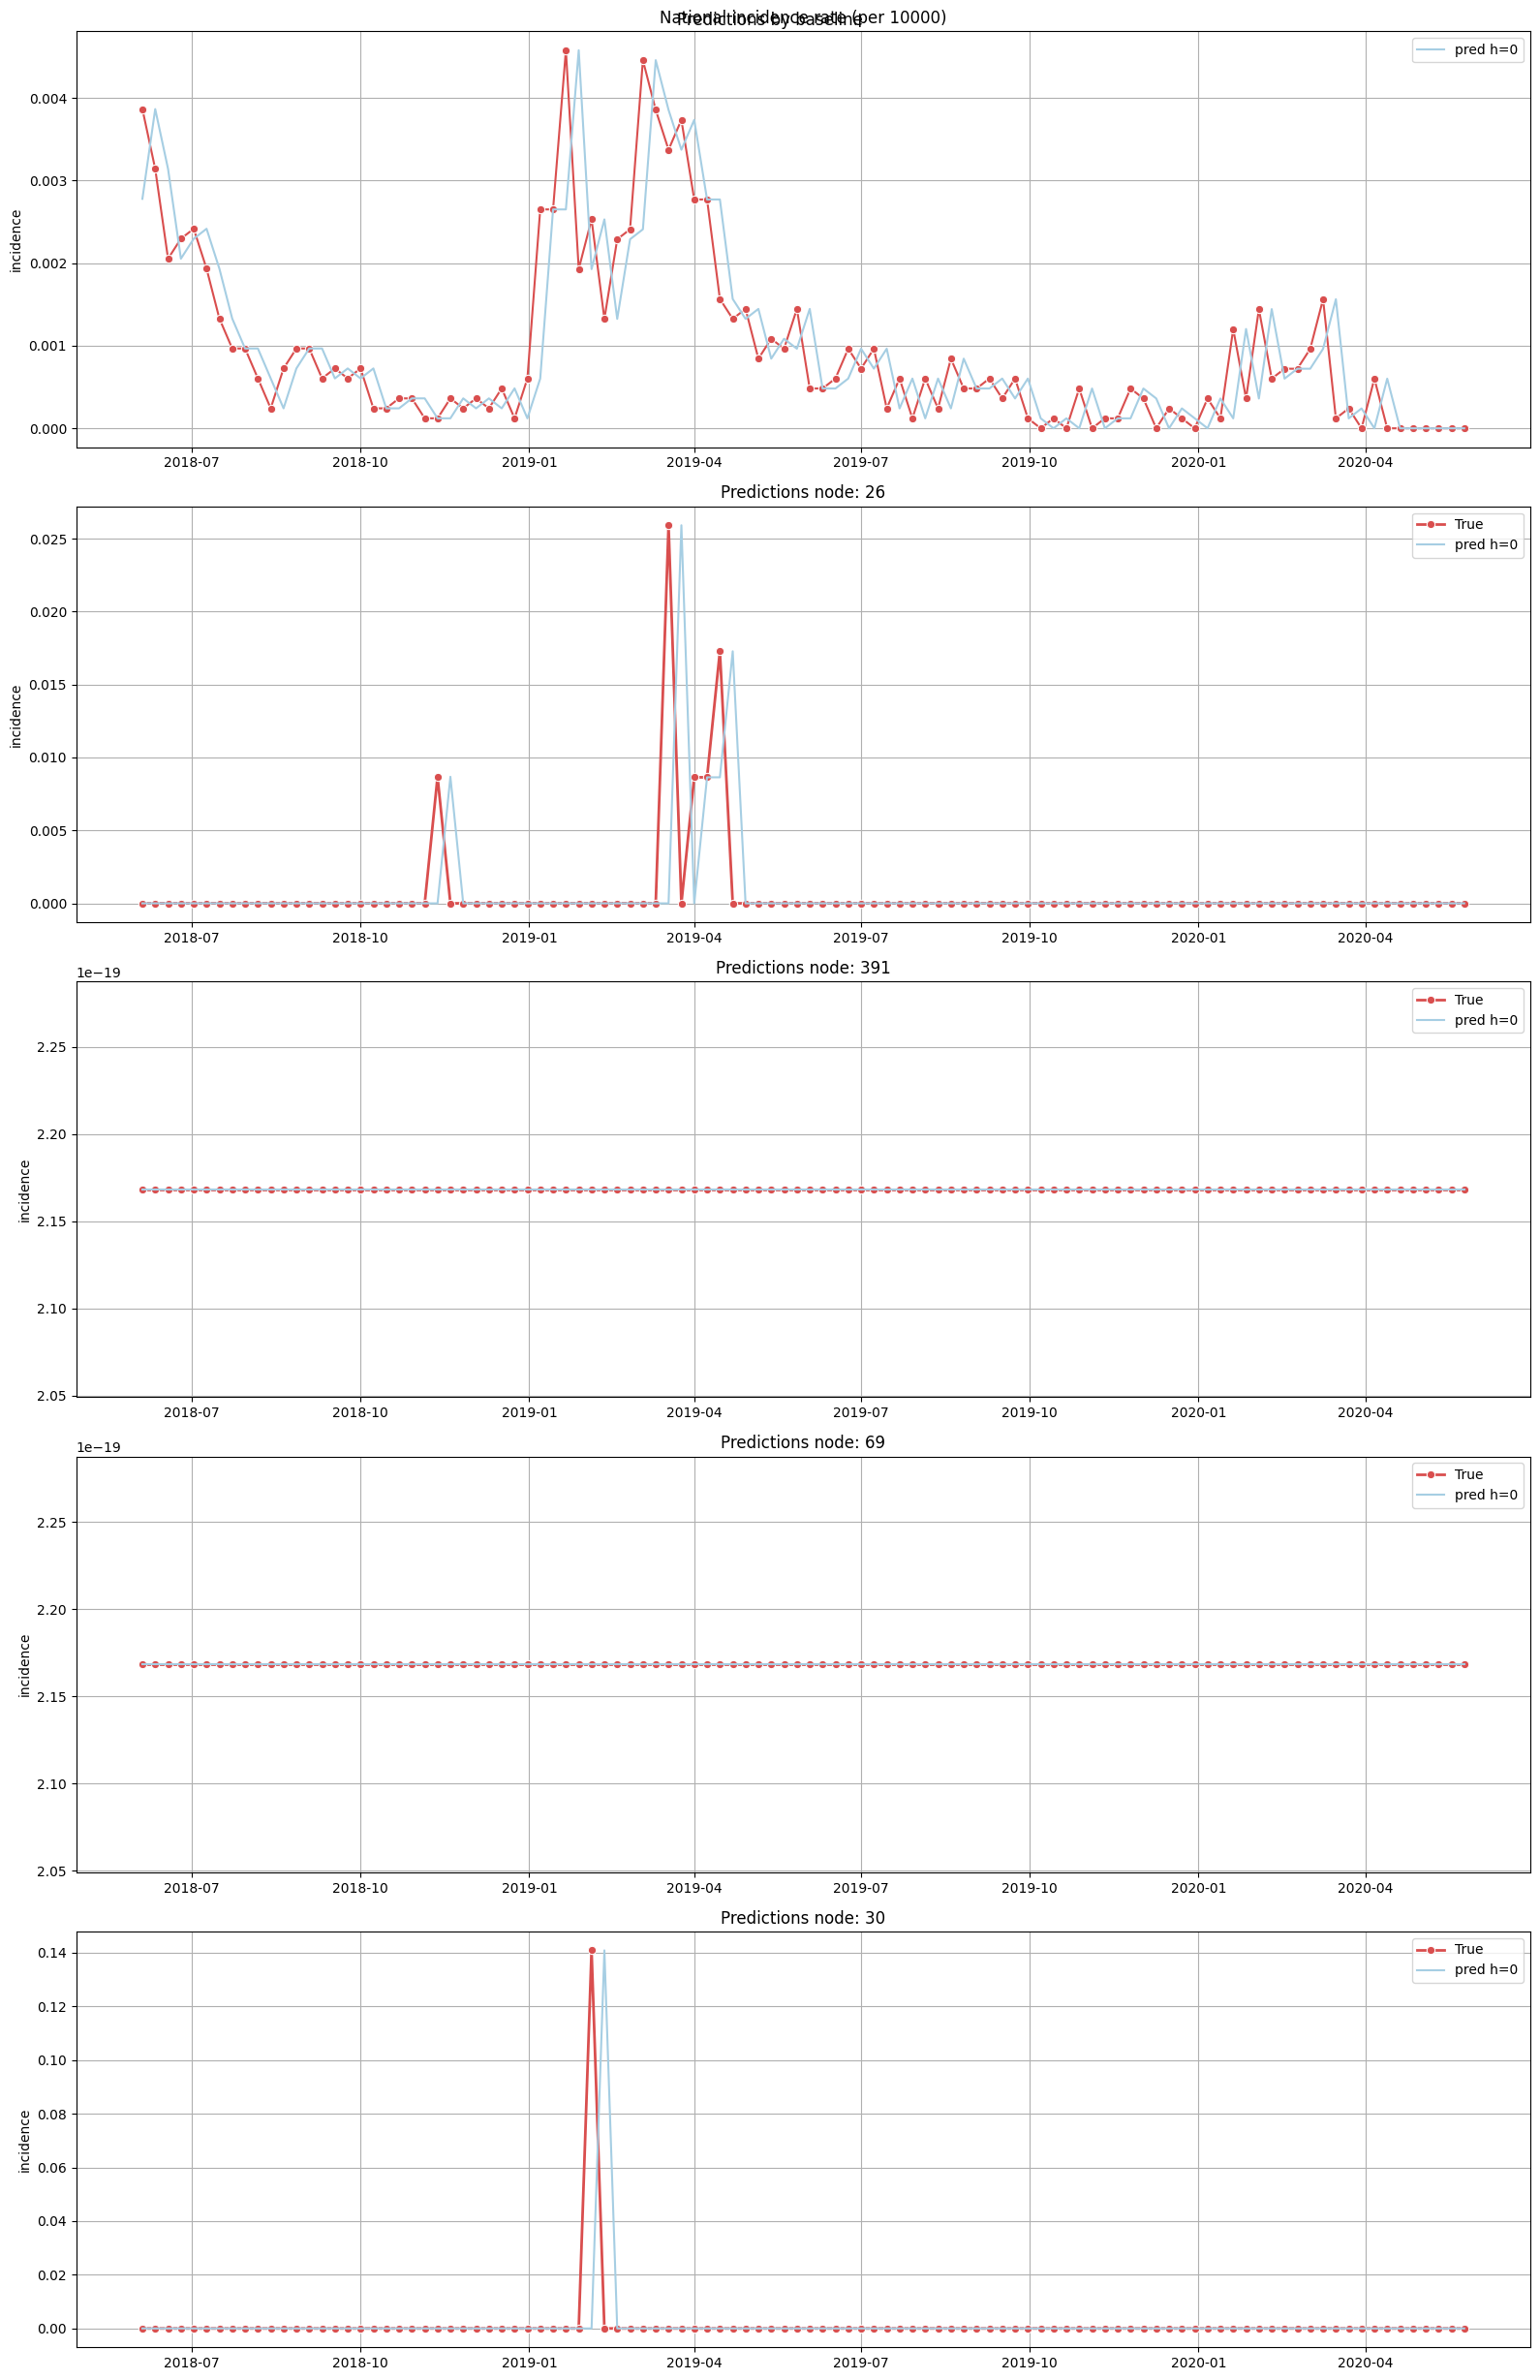

In [7]:
node = interesting_nodes

for ml in list(runner.models_dict.values()):

    ml.show_forecasts('test',node)

In [10]:
evaluator.add_evaluation()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:14<00:00,  2.34s/it]


Evaluator of ['SpatialGNNModel_gravity1', 'SpatialGNNModel_gravity2', 'SpatialGNNModel_gravity3', 'SpatialGNNModel_gravity4', 'SpatialGNNModel_identity_graph', 'SpatialGNNModel_boolean_neighbors_self', 'baseline'] for ['horizon_0']

2019-01-28 00:00:00


Text(0.5, 1.0, 'predictions - commuter1')

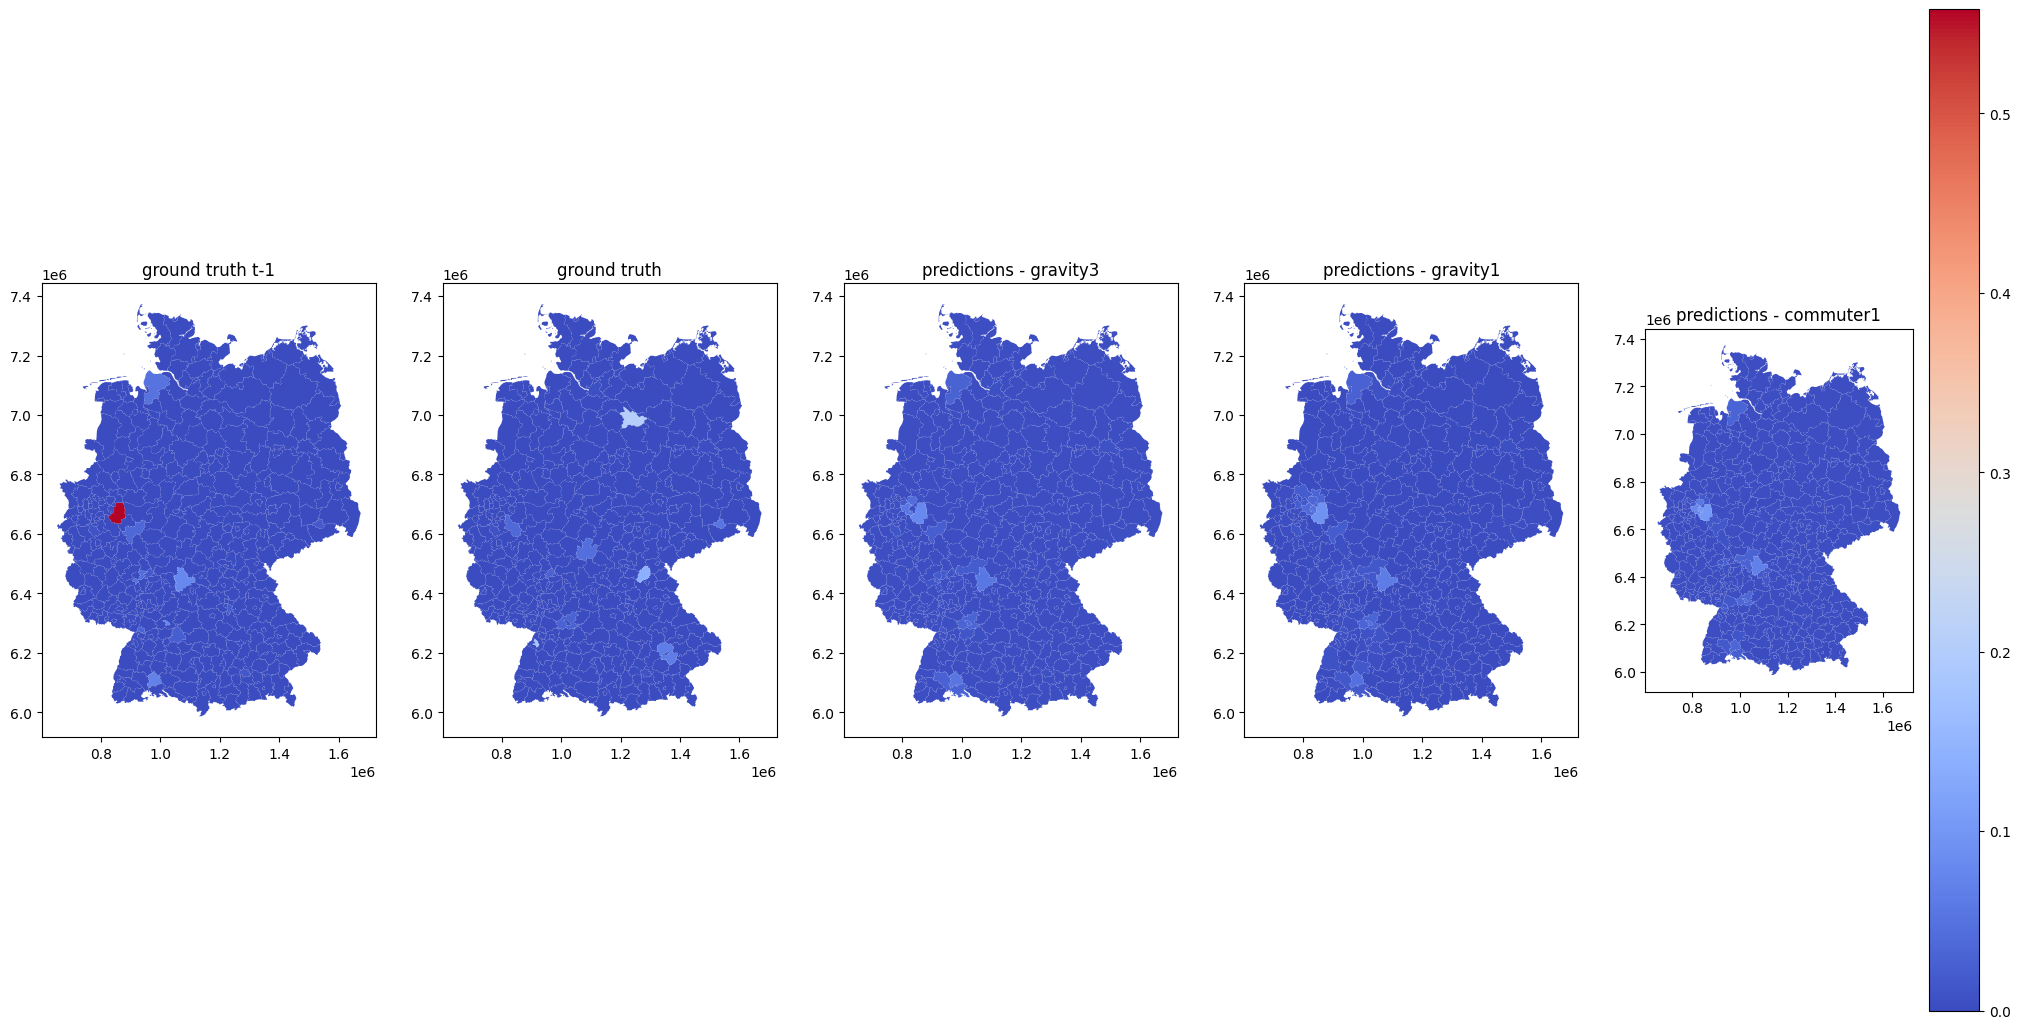

In [23]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

timestep_idx =34
unique_timesteps = evaluator.evaluation_compilations['horizon_0'].copy()['timestamp'].unique()
timestep = unique_timesteps[timestep_idx]

cp = evaluator.evaluation_compilations['horizon_0'].copy()

minvalue = 0.006
cp.set_index(['timestamp','node'], inplace= True) 

shapedata = runner.models_dict['SpatialGNNModel_boolean_neighbors_self'].dataloader.data['context']['shapedata']

print(timestep)

cp_cp = cp.copy().reset_index(drop = False)
cp_cp_neg1 = cp_cp[cp_cp['timestamp'] == unique_timesteps[timestep_idx-1]]
cp_cp = cp_cp[cp_cp['timestamp'] == timestep]

fig, axes = plt.subplots(1, 5, figsize = (25,15))
axes = axes.flatten()

cp_shapefile = gpd.GeoDataFrame(pd.merge(cp_cp, shapedata, on = 'node'))
cp_shapefileneg1= gpd.GeoDataFrame(pd.merge(cp_cp_neg1, shapedata, on = 'node'))

import matplotlib.pyplot as plt

# Find the global vmin and vmax across all the data to ensure consistent color scaling
# Assuming the 'incidence' and 'pred_*' columns are numerical and relevant for all plots
vmin = min(cp_shapefileneg1['incidence'].min(), cp_shapefile['incidence'].min(),
           cp_shapefile['pred_SpatialGNNModel_gravity1'].min(), cp_shapefile['pred_SpatialGNNModel_gravity2'].min(),
           cp_shapefile['pred_SpatialGNNModel_gravity3'].min())

vmax = max(cp_shapefileneg1['incidence'].max(), cp_shapefile['incidence'].max(),
           cp_shapefile['pred_SpatialGNNModel_gravity1'].max(), cp_shapefile['pred_SpatialGNNModel_gravity2'].max(),
           cp_shapefile['pred_SpatialGNNModel_gravity3'].max())



# Plot each DataFrame, apply coolwarm colormap, and set the same vmin and vmax
cp_shapefileneg1.plot(column='incidence', ax=axes[0], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='incidence', ax=axes[1], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='pred_SpatialGNNModel_gravity1', ax=axes[2], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='pred_SpatialGNNModel_gravity2', ax=axes[3], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='pred_SpatialGNNModel_gravity3', ax=axes[4], cmap='coolwarm', vmin=vmin, vmax=vmax, legend=True)

# Set titles for each subplot
axes[0].set_title('ground truth t-1')
axes[1].set_title('ground truth')
axes[2].set_title('predictions - gravity3')
axes[3].set_title('predictions - gravity1')
axes[4].set_title('predictions - commuter1')




In [14]:
runner.models_dict

{'SpatialGNNModel_gravity1': SpatialGNNModel(name='SpatialGNNModel_gravity1'),
 'SpatialGNNModel_gravity2': SpatialGNNModel(name='SpatialGNNModel_gravity2'),
 'SpatialGNNModel_gravity3': SpatialGNNModel(name='SpatialGNNModel_gravity3'),
 'SpatialGNNModel_gravity4': SpatialGNNModel(name='SpatialGNNModel_gravity4'),
 'SpatialGNNModel_identity_graph': SpatialGNNModel(name='SpatialGNNModel_identity_graph'),
 'SpatialGNNModel_boolean_neighbors_self': SpatialGNNModel(name='SpatialGNNModel_boolean_neighbors_self'),
 'persistence_baseline': PersistenceModel(name='baseline')}